In [4]:
%pip uninstall torch torchvision torchaudio -y
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
print("Installation 1 terminé")

Found existing installation: torch 2.7.1+cu118
Uninstalling torch-2.7.1+cu118:
  Successfully uninstalled torch-2.7.1+cu118
Found existing installation: torchvision 0.22.1+cu118
Uninstalling torchvision-0.22.1+cu118:
  Successfully uninstalled torchvision-0.22.1+cu118
Found existing installation: torchaudio 2.7.1+cu118
Uninstalling torchaudio-2.7.1+cu118:
  Successfully uninstalled torchaudio-2.7.1+cu118
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download-r2.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp313-cp313-win_amd64.whl.metadata (27 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp313-cp313-win_amd64.whl.metadata (6.8 kB)
Using cached https://download-r2.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp313-cp313-win_am

In [5]:
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchdiffeq import odeint
import os
print("Installation 2 terminé")

Installation terminé


In [6]:
print(torch.__version__)

2.7.1+cu118


In [7]:
torch.cuda.is_available()

True

Using device: cuda
NEURAL ODE FOR DRONE DYNAMICS

 Chargement du dataset...
Colonnes trouvées: ['t', 's_x', 's_y', 's_z', 's_roll', 's_pitch', 's_yaw', 's_vx', 's_vy', 's_vz', 'u_ux', 'u_uy', 'u_uz', 'u_uyaw', 'dt', 'ds_x', 'ds_y', 'ds_z', 'ds_roll', 'ds_pitch', 'ds_yaw', 'ds_vx', 'ds_vy', 'ds_vz']
Shape X: (15000, 13)
Shape Y: (15000, 9)
dt = 0.0195789337158203 s

 Normalisation des données...

 Création des trajectoires...
Création de 745 trajectoires
   Train: 596 trajectoires
   Test: 149 trajectoires

 Création du modèle Neural ODE...
   Nombre de paramètres: 203,273

 Entraînement...
Epoch  50/200 | Train Loss: 1.116618e-01 | Val Loss: 6.570065e-02
Epoch 100/200 | Train Loss: 8.356155e-02 | Val Loss: 6.543255e-02
Epoch 150/200 | Train Loss: 7.807332e-02 | Val Loss: 6.548209e-02
Epoch 200/200 | Train Loss: 8.014014e-02 | Val Loss: 6.536441e-02

 Génération des figures...


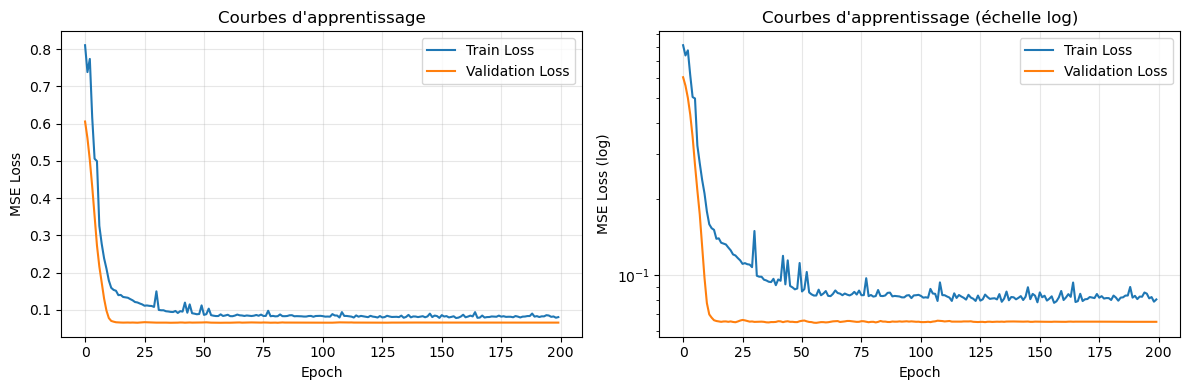

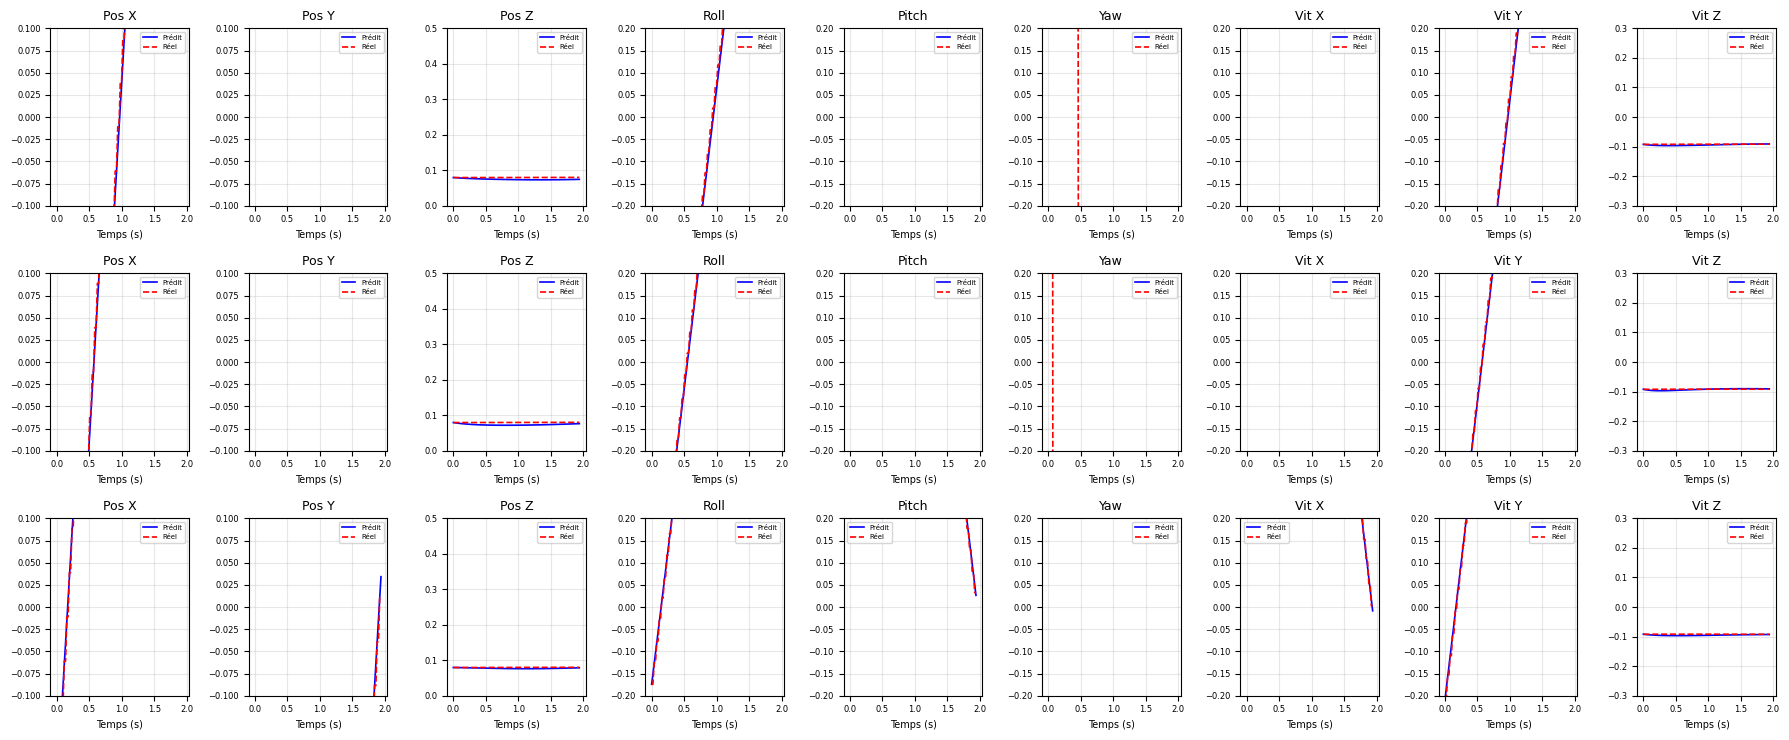

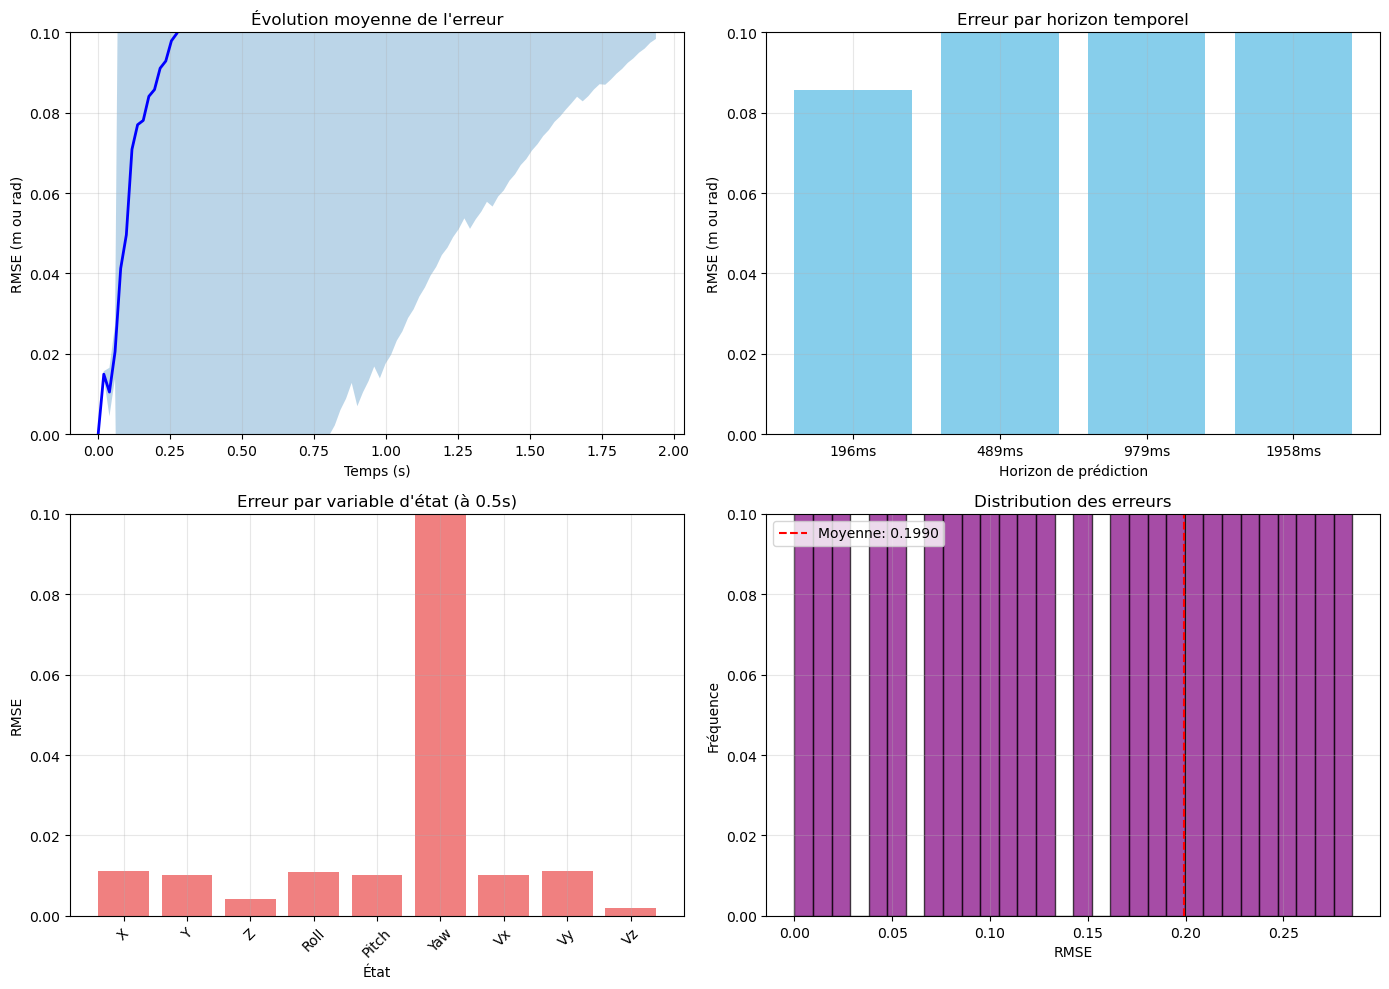


ANALYSE DES ERREURS
Horizon 196ms : RMSE = 0.0858 ± 0.1987
Horizon 489ms : RMSE = 0.1489 ± 0.2016
Horizon 979ms : RMSE = 0.2292 ± 0.2153
Horizon 1958ms : RMSE = 0.2851 ± 0.1867

Erreur par état (à 0.5s):
  X       : 0.0112
  Y       : 0.0102
  Z       : 0.0042
  Roll    : 0.0109
  Pitch   : 0.0101
  Yaw     : 0.4629
  Vx      : 0.0102
  Vy      : 0.0112
  Vz      : 0.0019


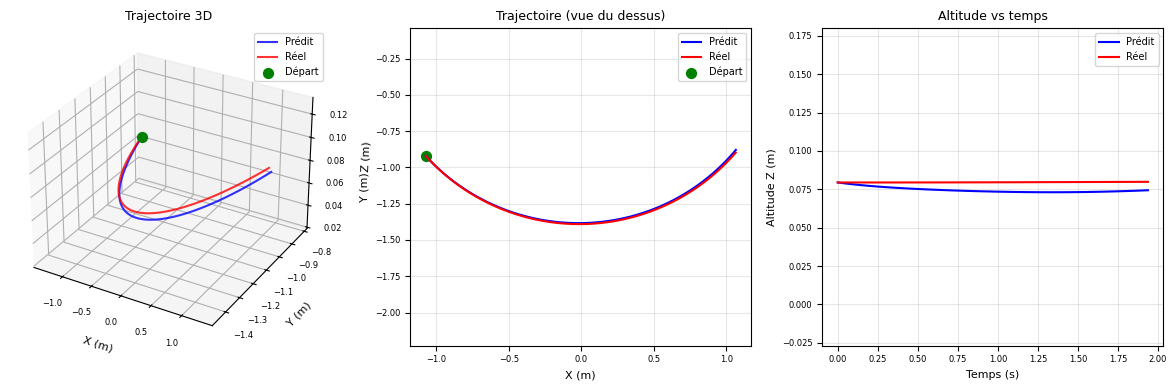


 Sauvegarde du modèle...
Modèle sauvegardé: neural_ode_drone.pth

ENTRAÎNEMENT TERMINÉ AVEC SUCCÈS!


In [15]:
# ============================================
# PARAMÈTRES
# ============================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Hyperparamètres
HIDDEN_SIZE = 256
LR = 1e-4
EPOCHS = 200
BATCH_SIZE = 64
SEQ_LEN = 100

# Colonnes
state_cols = ['s_x', 's_y', 's_z', 's_roll', 's_pitch', 's_yaw', 's_vx', 's_vy', 's_vz']

cmd_cols = ['u_ux', 'u_uy', 'u_uz', 'u_uyaw']

# Dérivées
deriv_cols = ['ds_x', 'ds_y', 'ds_z', 'ds_roll', 'ds_pitch', 'ds_yaw', 'ds_vx', 'ds_vy', 'ds_vz']

INPUT_DIM = len(state_cols) + len(cmd_cols)
OUTPUT_DIM = len(state_cols)

# ============================================
# 2. CHARGEMENT DU DATASET
# ============================================
def load_gazebo_dataset(csv_path):
    df = pd.read_csv("C:/Users/20220730/Downloads/tello_datasets/run_20260126_124602_circle_xy/ode.csv", sep=',')
    print(f"Colonnes trouvées: {df.columns.tolist()}")
   
    # Extraction des données
    states = df[state_cols].values
    commands = df[cmd_cols].values
    derivatives = df[deriv_cols].values
    dt = df['dt'].values[0] if 'dt' in df.columns else 0.01
   
    X = np.hstack([states, commands])
    Y = derivatives
   
    print(f"Shape X: {X.shape}")
    print(f"Shape Y: {Y.shape}")
    print(f"dt = {dt} s")
   
    return X, Y, dt, states, commands

# ============================================
# 3. CRÉATION DES TRAJECTOIRES POUR NEURAL ODE
# ============================================
def create_trajectories(X, Y, seq_len=SEQ_LEN, stride=20):
    trajectories = []
   
    for i in range(0, len(X) - seq_len, stride):
        X_seq = X[i:i+seq_len]
       
        # État initial (sans commande)
        x0_states = torch.tensor(X_seq[0, :len(state_cols)], dtype=torch.float32)
       
        # Commande initiale
        x0_cmd = torch.tensor(X_seq[0, len(state_cols):], dtype=torch.float32)
       
        # Commandes sur toute la séquence
        cmd_seq = torch.tensor(X_seq[:, len(state_cols):], dtype=torch.float32)
       
        # États réels sur la séquence
        true_states = torch.tensor(X_seq[:, :len(state_cols)], dtype=torch.float32)
       
        trajectories.append((x0_states, x0_cmd, cmd_seq, true_states))
   
    print(f"Création de {len(trajectories)} trajectoires")
    return trajectories

# ============================================
# 4. DATASET PYTORCH
# ============================================
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories
   
    def __len__(self):
        return len(self.trajectories)
   
    def __getitem__(self, idx):
        return self.trajectories[idx]

# ============================================
# 5. NEURAL ODE FUNCTION (f_θ)
# ============================================
class ODEFunc(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
       
        # Initialisation
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight, gain=0.5)
                nn.init.zeros_(layer.bias)
   
    def forward(self, t, x_with_cmd):
        return self.net(x_with_cmd)

# ============================================
# 6. MODÈLE NEURAL ODE COMPLET
# ============================================
class NeuralODEModel(nn.Module):
    def __init__(self, ode_func, dt=0.01):
        super().__init__()
        self.ode_func = ode_func
        self.dt = dt
   
    def forward(self, t_span, x0_states, cmd_seq):
        batch_size = x0_states.shape[0]
        seq_len = cmd_seq.shape[1]
        state_dim = x0_states.shape[1]
       
        # Initialisation de la trajectoire
        trajectory = [x0_states]
        state = x0_states
       
        for i in range(seq_len - 1):
            cmd = cmd_seq[:, i, :]
           
            # Concaténation état-commande
            state_with_cmd = torch.cat([state, cmd], dim=1)
           
            # Calcul de la dérivée
            deriv = self.ode_func(t_span[i] if len(t_span) > i else t_span[0], state_with_cmd)
           
            # Intégration d'Euler
            state = state + deriv * self.dt
           
            trajectory.append(state)
       
        return torch.stack(trajectory, dim=1)

# ============================================
# 7. ENTRAÎNEMENT
# ============================================
def train_neural_ode(model, train_loader, val_loader, epochs=EPOCHS, dt=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-6)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
   
    train_losses = []
    val_losses = []
   
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            if len(batch) == 4:
                x0_states, x0_cmd, cmd_seq, true_states = batch
            else:
                x0_states, cmd_seq, true_states = batch
           
            x0_states = x0_states.to(DEVICE)
            cmd_seq = cmd_seq.to(DEVICE)
            true_states = true_states.to(DEVICE)
           
            if x0_states.dim() == 1:
                x0_states = x0_states.unsqueeze(0)  # (1, 9)
            if cmd_seq.dim() == 2:
                cmd_seq = cmd_seq.unsqueeze(0)  # (1, seq_len, 4)
            if true_states.dim() == 2:
                true_states = true_states.unsqueeze(0)  # (1, seq_len, 9)
           
            t_span = torch.linspace(0, SEQ_LEN * dt, SEQ_LEN, device=DEVICE)
           
            optimizer.zero_grad()

            pred_states = model(t_span, x0_states, cmd_seq)

            loss = criterion(pred_states, true_states)
            loss.backward()
           
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
       
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 4:
                    x0_states, x0_cmd, cmd_seq, true_states = batch
                else:
                    x0_states, cmd_seq, true_states = batch
               
                x0_states = x0_states.to(DEVICE)
                cmd_seq = cmd_seq.to(DEVICE)
                true_states = true_states.to(DEVICE)
               
                if x0_states.dim() == 1:
                    x0_states = x0_states.unsqueeze(0)
                if cmd_seq.dim() == 2:
                    cmd_seq = cmd_seq.unsqueeze(0)
                if true_states.dim() == 2:
                    true_states = true_states.unsqueeze(0)
               
                t_span = torch.linspace(0, SEQ_LEN * dt, SEQ_LEN, device=DEVICE)
                pred_states = model(t_span, x0_states, cmd_seq)
                loss = criterion(pred_states, true_states)
                val_loss += loss.item()
       
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
       
        scheduler.step()
       
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_losses[-1]:.6e} | Val Loss: {val_losses[-1]:.6e}")
   
    return train_losses, val_losses
# ============================================
# 8. VISUALISATION DES PRÉDICTIONS
# ============================================
def plot_predictions(model, test_trajectories, dt=0.01, num_examples=3):
    model.eval()
    var_names = ['Pos X', 'Pos Y', 'Pos Z', 'Roll', 'Pitch', 'Yaw', 'Vit X', 'Vit Y', 'Vit Z']
    
    fig, axes = plt.subplots(num_examples, 9, figsize=(18, 2.5*num_examples))
    
    if num_examples == 1:
        axes = axes.reshape(1, -1)
    
    time_axis = np.arange(SEQ_LEN) * dt
    
    y_limits = {
        'Pos X': [-0.1, 0.1],
        'Pos Y': [-0.1, 0.1],
        'Pos Z': [0, 0.5],
        'Roll': [-0.2, 0.2],
        'Pitch': [-0.2, 0.2],
        'Yaw': [-0.2, 0.2],
        'Vit X': [-0.2, 0.2],
        'Vit Y': [-0.2, 0.2],
        'Vit Z': [-0.3, 0.3], 
    }
    
    for i in range(min(num_examples, len(test_trajectories))):
        x0_states, x0_cmd, cmd_seq, true_states = test_trajectories[i]
        x0_states = x0_states.to(DEVICE)
        cmd_seq = cmd_seq.to(DEVICE)
        t_span = torch.linspace(0, SEQ_LEN * dt, SEQ_LEN, device=DEVICE)
    
        with torch.no_grad():
            x0_batch = x0_states.unsqueeze(0)
            cmd_batch = cmd_seq.unsqueeze(0)
            pred = model(t_span, x0_batch, cmd_batch).detach().cpu().numpy()[0]
            true = true_states.cpu().numpy()
    
        for j, name in enumerate(var_names):
            ax = axes[i, j]
            ax.plot(time_axis, pred[:, j], 'b-', label='Prédit', linewidth=1.2)
            ax.plot(time_axis, true[:, j], 'r--', label='Réel', linewidth=1.2)
    
            if name in y_limits:
                ax.set_ylim(y_limits[name])
    
            ax.set_title(name, fontsize=9)
            ax.set_xlabel('Temps (s)', fontsize=7)
            ax.tick_params(labelsize=6)
            ax.legend(fontsize=5)
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('neural_ode_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# 9. ANALYSE DES ERREURS
# ============================================
def plot_error_analysis(model, test_trajectories, dt=0.01):
    model.eval()
   
    all_errors = []
    prediction_horizons = [10, 25, 50, 100]
   
    state_names = ['X', 'Y', 'Z', 'Roll', 'Pitch', 'Yaw', 'Vx', 'Vy', 'Vz']
   
    with torch.no_grad():
        for traj in test_trajectories[:50]:
            x0_states, x0_cmd, cmd_seq, true_states = traj
            x0_states = x0_states.to(DEVICE)
            cmd_seq = cmd_seq.to(DEVICE)
           
            t_span = torch.linspace(0, SEQ_LEN * dt, SEQ_LEN, device=DEVICE)
           
            x0_batch = x0_states.unsqueeze(0)
            cmd_batch = cmd_seq.unsqueeze(0)
            pred_states = model(t_span, x0_batch, cmd_batch).detach().cpu().numpy()
            pred_states = pred_states[0]
           
            true_states = true_states.cpu().numpy()
           
            errors = np.sqrt(np.mean((pred_states - true_states)**2, axis=1))
            all_errors.append(errors)
   
    all_errors = np.array(all_errors)
    mean_errors = np.mean(all_errors, axis=0)
    std_errors = np.std(all_errors, axis=0)
   
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
   
    # Évolution de l'erreur dans le temps
    time_steps = np.arange(SEQ_LEN) * dt
    ax1.plot(time_steps, mean_errors, 'b-', linewidth=2)
    ax1.fill_between(time_steps, mean_errors - std_errors, mean_errors + std_errors, alpha=0.3)
    ax1.set_xlabel('Temps (s)')
    ax1.set_ylabel('RMSE (m ou rad)')
    ax1.set_title('Évolution moyenne de l\'erreur')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 0.1])
   
    # Erreur à différents horizons
    horizon_errors = []
    for horizon in prediction_horizons:
        idx = min(horizon, SEQ_LEN-1)
        horizon_errors.append(np.mean(mean_errors[idx]))
   
    ax2.bar([f"{h*dt*1000:.0f}ms" for h in prediction_horizons], horizon_errors, color='skyblue')
    ax2.set_xlabel('Horizon de prédiction')
    ax2.set_ylabel('RMSE (m ou rad)')
    ax2.set_title('Erreur par horizon temporel')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 0.1])
   
    # Erreur par état (à horizon 0.5s)
    horizon_50 = min(50, SEQ_LEN-1)
    errors_per_state = []
    for traj in test_trajectories[:50]:
        x0_states, x0_cmd, cmd_seq, true_states = traj
        x0_states = x0_states.to(DEVICE)
        cmd_seq = cmd_seq.to(DEVICE)
       
        t_span = torch.linspace(0, SEQ_LEN * dt, SEQ_LEN, device=DEVICE)
        x0_batch = x0_states.unsqueeze(0)
        cmd_batch = cmd_seq.unsqueeze(0)
        pred_states = model(t_span, x0_batch, cmd_batch).detach().cpu().numpy()
        pred_states = pred_states[0]
        true_states = true_states.cpu().numpy()
       
        err_state = np.sqrt(np.mean((pred_states[:horizon_50] - true_states[:horizon_50])**2, axis=0))
        errors_per_state.append(err_state)
   
    mean_err_state = np.mean(errors_per_state, axis=0)
    ax3.bar(state_names, mean_err_state, color='lightcoral')
    ax3.set_xlabel('État')
    ax3.set_ylabel('RMSE')
    ax3.set_title('Erreur par variable d\'état (à 0.5s)')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0, 0.1])  
    
    # Distribution des erreurs
    ax4.hist(mean_errors, bins=30, alpha=0.7, color='purple', edgecolor='black')
    ax4.axvline(np.mean(mean_errors), color='red', linestyle='--', label=f'Moyenne: {np.mean(mean_errors):.4f}')
    ax4.set_xlabel('RMSE')
    ax4.set_ylabel('Fréquence')
    ax4.set_title('Distribution des erreurs')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim([0, 0.1])
   
    plt.tight_layout()
    plt.savefig('neural_ode_error_analysis.png', dpi=150)
    plt.show()
   
    # Affichage des métriques
    print("\n" + "="*60)
    print("ANALYSE DES ERREURS")
    print("="*60)
    for horizon, dt_h in zip(prediction_horizons, [dt*h for h in prediction_horizons]):
        idx = min(horizon, SEQ_LEN-1)
        print(f"Horizon {dt_h*1000:.0f}ms : RMSE = {mean_errors[idx]:.4f} ± {std_errors[idx]:.4f}")
   
    print("\nErreur par état (à 0.5s):")
    for name, err in zip(state_names, mean_err_state):
        print(f"  {name:8s}: {err:.4f}")

# ============================================
# 10. VISUALISATION 3D
# ============================================
def plot_3d_trajectory(model, trajectory, dt=0.01):
    model.eval()
    x0_states, x0_cmd, cmd_seq, true_states = trajectory

    x0_states = x0_states.to(DEVICE)
    cmd_seq = cmd_seq.to(DEVICE)
    t_span = torch.linspace(0, SEQ_LEN * dt, SEQ_LEN, device=DEVICE)

    with torch.no_grad():
        x0_batch = x0_states.unsqueeze(0)
        cmd_batch = cmd_seq.unsqueeze(0)
        pred_states = model(t_span, x0_batch, cmd_batch).detach().cpu().numpy()
        pred_states = pred_states[0]
        true_states = true_states.cpu().numpy()

    fig = plt.figure(figsize=(12, 4))

    # 3D
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.plot(pred_states[:, 0], pred_states[:, 1], pred_states[:, 2], 'b-', label='Prédit', linewidth=1.5, alpha=0.8)
    ax1.plot(true_states[:, 0], true_states[:, 1], true_states[:, 2], 'r-', label='Réel', linewidth=1.5, alpha=0.8)
    ax1.scatter(pred_states[0, 0], pred_states[0, 1], pred_states[0, 2], c='green', s=50, label='Départ')

    all_x = np.concatenate([pred_states[:, 0], true_states[:, 0]])
    all_y = np.concatenate([pred_states[:, 1], true_states[:, 1]])
    all_z = np.concatenate([pred_states[:, 2], true_states[:, 2]])

    x_range = all_x.max() - all_x.min()
    y_range = all_y.max() - all_y.min()
    z_range = all_z.max() - all_z.min()

    ax1.set_xlim([all_x.min() - 0.2*x_range, all_x.max() + 0.2*x_range])
    ax1.set_ylim([all_y.min() - 0.2*y_range, all_y.max() + 0.2*y_range])
    ax1.set_zlim([all_z.min() - 8*z_range, all_z.max() + 8*z_range])

    ax1.set_xlabel('X (m)', fontsize=8)
    ax1.set_ylabel('Y (m)', fontsize=8)
    ax1.set_zlabel('Z (m)', fontsize=8)
    ax1.set_title('Trajectoire 3D', fontsize=9)
    ax1.tick_params(labelsize=6)
    ax1.legend(fontsize=7)

    # Projection XY
    ax2 = fig.add_subplot(132)
    ax2.plot(pred_states[:, 0], pred_states[:, 1], 'b-', label='Prédit', linewidth=1.5)
    ax2.plot(true_states[:, 0], true_states[:, 1], 'r-', label='Réel', linewidth=1.5)
    ax2.scatter(pred_states[0, 0], pred_states[0, 1], c='green', s=50, label='Départ')
    
    ax2.set_xlim([all_x.min() - 0.2*x_range, all_x.max() + 0.2*x_range])
    ax2.set_ylim([all_y.min() - 0.2*y_range, all_y.max() + 0.2*y_range])
    
    ax2.set_xlabel('X (m)', fontsize=8)
    ax2.set_ylabel('Y (m)', fontsize=8)
    ax2.set_title('Trajectoire (vue du dessus)', fontsize=9)
    ax2.tick_params(labelsize=6)
    ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    
    # Altitude dans le temps
    ax3 = fig.add_subplot(133)
    time = np.arange(SEQ_LEN) * dt
    ax3.plot(time, pred_states[:, 2], 'b-', label='Prédit', linewidth=1.5)
    ax3.plot(time, true_states[:, 2], 'r-', label='Réel', linewidth=1.5)
    
    z_min = min(pred_states[:, 2].min(), true_states[:, 2].min())
    z_max = max(pred_states[:, 2].max(), true_states[:, 2].max())
    ax3.set_ylim([z_min - 0.1, z_max + 0.1])
    
    ax3.set_xlabel('Temps (s)', fontsize=8)
    ax3.set_ylabel('Altitude Z (m)', fontsize=8)
    ax3.set_title('Altitude vs temps', fontsize=9)
    ax3.tick_params(labelsize=6)
    ax3.legend(fontsize=7)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('neural_ode_3d.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# 11. COURBES D'APPRENTISSAGE
# ============================================
def plot_training_curves(train_losses, val_losses):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
   
    # Loss linéaire
    ax1.plot(train_losses, label='Train Loss', linewidth=1.5)
    ax1.plot(val_losses, label='Validation Loss', linewidth=1.5)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('MSE Loss')
    ax1.set_title('Courbes d\'apprentissage')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
   
    # Loss log
    ax2.semilogy(train_losses, label='Train Loss', linewidth=1.5)
    ax2.semilogy(val_losses, label='Validation Loss', linewidth=1.5)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MSE Loss (log)')
    ax2.set_title('Courbes d\'apprentissage (échelle log)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
   
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

# ============================================
# 12. MAIN
# ============================================
def main():
    print("="*60)
    print("NEURAL ODE FOR DRONE DYNAMICS")
    print("="*60)
   
    # Chargement des données
    print("\n Chargement du dataset...")
    csv_path = "C:/Users/20220730/Downloads/tello_datasets/run_20260126_124602_circle_xy/ode.csv"
   
    try:
        X, Y, dt, states, commands = load_gazebo_dataset(csv_path)
    except FileNotFoundError:
        print(f"Fichier non trouvé: {csv_path}")
        print("Veuillez mettre le chemin correct vers votre CSV")
        return
   
    # Normalisation
    print("\n Normalisation des données...")
    from sklearn.preprocessing import StandardScaler
    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()
   
    X_normalized = scaler_X.fit_transform(X)
    Y_normalized = scaler_Y.fit_transform(Y)
   
    # Création des trajectoires
    print("\n Création des trajectoires...")
    trajectories = create_trajectories(X_normalized, Y_normalized, seq_len=SEQ_LEN)
   
    # Split train/test
    train_size = int(0.8 * len(trajectories))
    train_traj = trajectories[:train_size]
    test_traj = trajectories[train_size:]
   
    train_dataset = TrajectoryDataset(train_traj)
    test_dataset = TrajectoryDataset(test_traj)
   
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
   
    print(f"   Train: {len(train_traj)} trajectoires")
    print(f"   Test: {len(test_traj)} trajectoires")
   
    # Création du modèle
    print("\n Création du modèle Neural ODE...")
    ode_func = ODEFunc(INPUT_DIM, HIDDEN_SIZE, OUTPUT_DIM).to(DEVICE)
    model = NeuralODEModel(ode_func, dt=dt).to(DEVICE)
   
    total_params = sum(p.numel() for p in model.parameters())
    print(f"   Nombre de paramètres: {total_params:,}")
   
    # Entraînement
    print("\n Entraînement...")
    train_losses, val_losses = train_neural_ode(model, train_loader, test_loader, epochs=EPOCHS, dt=dt)
   
    # Visualisations
    print("\n Génération des figures...")
    plot_training_curves(train_losses, val_losses)
    plot_predictions(model, test_traj, dt=dt, num_examples=3)
    plot_error_analysis(model, test_traj, dt=dt)
    plot_3d_trajectory(model, test_traj[0], dt=dt)
   
    # Sauvegarde
    print("\n Sauvegarde du modèle...")
    torch.save({
        'model_state_dict': model.state_dict(),
        'ode_func_state_dict': ode_func.state_dict(),
        'scaler_X': scaler_X,
        'scaler_Y': scaler_Y,
        'dt': dt,
        'hidden_size': HIDDEN_SIZE,
        'input_dim': INPUT_DIM,
        'output_dim': OUTPUT_DIM,
    }, 'neural_ode_drone.pth')
    print("Modèle sauvegardé: neural_ode_drone.pth")
   
    print("\n" + "="*60)
    print("ENTRAÎNEMENT TERMINÉ AVEC SUCCÈS!")
    print("="*60)

if __name__ == "__main__":
    main()